# Regression on California housing dataset

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, DecisionTreeRegressor

## Import data

In [2]:
X, y = fetch_california_housing(return_X_y = True, as_frame=True)

In [3]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [27]:
y # price in hundreds of thousands $

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

## Split data

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20)

## Create and use model

In [9]:
lr = LinearRegression()

In [11]:
lr.fit(X_train, y_train)

LinearRegression()

In [12]:
random_house = X_test.sample()

In [13]:
random_house

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
9430,2.3482,52.0,6.891892,1.178378,627.0,3.389189,38.28,-122.9


In [26]:
y_test.loc[9430] # price in hundreds of thousands $

1.635

In [16]:
lr.predict(random_house)

array([1.82871285])

## Check score

In [21]:
lr.score(X_test, y_test) # R squared

0.5757877060324508

In [23]:
y_pred = lr.predict(X_test)

In [30]:
rmse = mean_squared_error(y_test, y_pred, squared=False) #Root mean squared error
rmse

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.7455813830127764

In [37]:
rmse = root_mean_squared_error(y_test, y_pred) #Root mean squared error
rmse

0.7455813830127764

Root Mean Squared Error is 74558 dollars

In [31]:
# To explain the seemingly big RMSE, let's explore the distribution of prices
y.describe()

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64

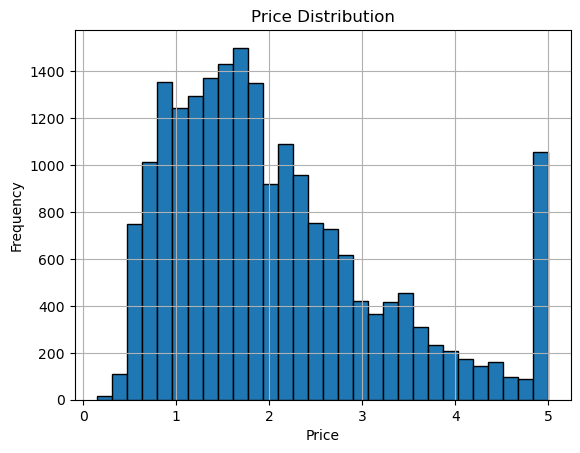

In [33]:
y.hist(bins=30, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

<Axes: ylabel='MedHouseVal'>

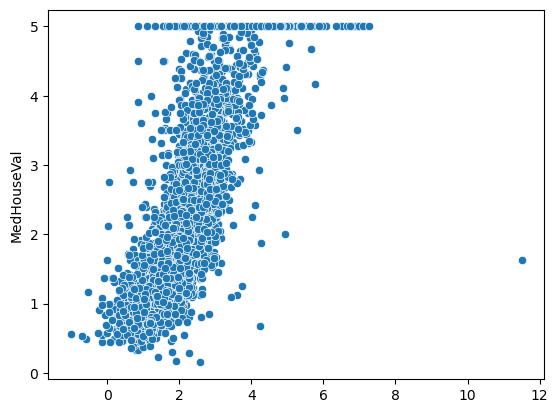

In [41]:
sns.scatterplot(x=y_pred, y=y_test)

In [42]:
lr.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [43]:
X_train.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [44]:
lr.intercept_

-37.02327770606417

In [45]:
# price = -37 + 4.5 * MedInc + 0.45 + 0.009 * HouseAge.......

## Train a decision tree on this dataset and see how good it is

In [53]:
dt = DecisionTreeRegressor(max_depth = 5)

In [54]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

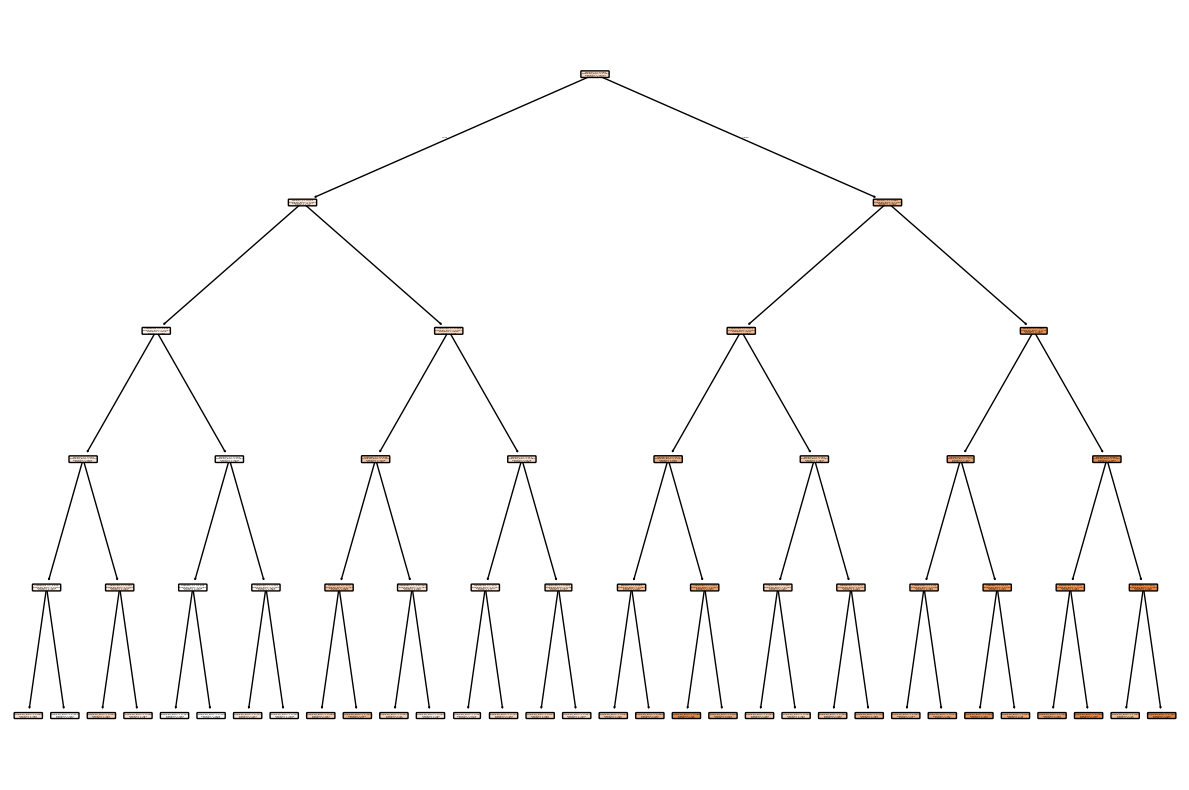

In [55]:
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names = X_train.columns,
    class_names = y_train.unique(),
    filled=True,
    rounded=True,
    impurity=True,
)
plt.tight_layout()
plt.show()

In [56]:
dt.score(X_test, y_test)

0.5997321244428706

In [57]:
y_pred = dt.predict(X_test)

In [58]:
rmse = root_mean_squared_error(y_test, y_pred) #Root mean squared error
rmse

0.7242338143386247